# CNN-Only Intra-Subject Baseline

Optimised CNN for MEG mental-task classification (intra-subject setting).

**Architecture:** two-layer spatiotemporal CNN (temporal conv → spatial conv) + Global Average Pooling + linear classifier. This is the convolutional front-end of the EEG Conformer, stripped of the transformer.

**Pipeline:**
1. Load & preprocess data via shared `protocol_utils`
2. Grid search over `kernel_temp`, `n_filters`, `dropout` — select by **val file accuracy**
3. Retrain best config on train + val for the winning number of epochs
4. Evaluate once on held-out test set

## 1. Imports

In [1]:
import sys
import itertools

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# shared protocol utilities live one directory up
sys.path.append('..')
from protocol_utils import (
    DatasetPaths,
    PreprocessConfig,
    list_files,
    make_windows,
    split_files_train_val,
    file_accuracy_from_logits,
    summarize_logits,
    CLASS_NAMES,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 2. Data Loading

`protocol_utils` handles the full preprocessing chain per file:
- **Z-score normalisation** per sensor per file — removes amplitude differences between sensors and recordings
- **Downsampling** by factor 4: raw ~2034 Hz → ~508 Hz
- **Sliding windows**: 512 samples (~1 s) with 256-sample stride (50% overlap)

The train/val split is **file-level** with `val_frac=0.2, seed=0` (fixed by protocol). Whole recordings go to one side — no leakage from windows of the same file appearing in both train and val.

We retrieve `val_groups` from `make_windows` so we can aggregate window logits to **file-level accuracy** during training without needing the file paths again.

In [2]:
paths = DatasetPaths(data_root='../Final Project data')
cfg   = PreprocessConfig(downsample_factor=4, window_size=512, stride=128)

# protocol-fixed file-level split: val_frac=0.2, seed=0
train_files, val_files = split_files_train_val(
    list_files(paths.intra_train), val_frac=0.2, seed=0
)
test_files = list_files(paths.intra_test)

# make_windows returns (X, y, groups) — groups[i] is the source-file index of window i
# we need val_groups so we can compute file-level accuracy during the grid search
X_train, y_train, _            = make_windows(train_files, cfg)
X_val,   y_val,   val_groups   = make_windows(val_files,   cfg)
X_test,  y_test,  test_groups  = make_windows(test_files,  cfg)

print(f'Train : {X_train.shape}  ({len(train_files)} files)')
print(f'Val   : {X_val.shape}  ({len(val_files)} files)')
print(f'Test  : {X_test.shape}  ({len(test_files)} files)')
print(f'\nWindow shape: (n_sensors={X_train.shape[1]}, window_size={X_train.shape[2]})')

Train : (1716, 248, 512)  (26 files)
Val   : (396, 248, 512)  (6 files)
Test  : (528, 248, 512)  (8 files)

Window shape: (n_sensors=248, window_size=512)


## 3. Model Architecture

Two convolutional layers followed by Global Average Pooling (GAP).

### ConvModule — layer-by-layer dimensions

| Layer | Input shape | Output shape | What it learns |
|---|---|---|---|
| Temporal conv `(1, kernel_temp)` | `(B, 1, 248, 512)` | `(B, F, 248, 512−kt+1)` | Local temporal patterns; slides along time, sensors untouched |
| BatchNorm | — | — | — |
| Spatial conv `(248, 1)` | `(B, F, 248, T')` | `(B, F, 1, T')` | Which sensors co-activate; collapses all 248 sensors |
| BatchNorm + ELU | — | — | — |
| AvgPool `(1,75)` stride `(1,15)` | `(B, F, 1, T')` | `(B, F, 1, T'')` | Temporal smoothing and compression |
| Dropout | — | — | — |
| squeeze + permute | `(B, F, 1, T'')` | `(B, T'', F)` | Reshape for GAP |

where `T' = 512 − kernel_temp + 1` and `T'' = ⌊(T'−75)/15⌋ + 1`.

For `kernel_temp=25, F=40`: T'=488, T''=28.  
For `kernel_temp=201, F=40`: T'=312, T''=16.

### CNNOnly — top-level

| Layer | Input | Output |
|---|---|---|
| ConvModule | `(B, 1, 248, 512)` | `(B, T'', F)` |
| GAP `mean(dim=1)` | `(B, T'', F)` | `(B, F)` |
| Linear `(F, 4)` | `(B, F)` | `(B, 4)` logits |

GAP collapses the time dimension by averaging all T'' feature vectors. This makes the model agnostic to the exact value of T'', so `kernel_temp` can vary freely in the grid search without touching the classifier head.

In [3]:
class ConvModule(nn.Module):
    """
    Two-layer spatiotemporal feature extractor.

    Temporal conv: kernel height=1, so it slides along time independently
    at each sensor. Each filter learns a different temporal pattern over
    kernel_temp consecutive samples.

    Spatial conv: kernel width=1, so it collapses all n_channels sensors
    into one mixed representation at each timestep. Learns which sensors
    co-activate for each temporal feature.
    """
    def __init__(self, n_channels=248, n_filters=40, kernel_temp=25,
                 pool_size=75, pool_stride=15, dropout=0.5):
        super().__init__()

        # (B, 1, 248, W) -> (B, n_filters, 248, W - kernel_temp + 1)
        self.temporal = nn.Sequential(
            nn.Conv2d(1, n_filters, kernel_size=(1, kernel_temp), bias=False),
            nn.BatchNorm2d(n_filters),
        )

        # (B, n_filters, 248, T') -> (B, n_filters, 1, T'')
        self.spatial = nn.Sequential(
            nn.Conv2d(n_filters, n_filters, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(n_filters),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, pool_size), stride=(1, pool_stride)),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = self.temporal(x)       # (B, n_filters, 248, T')
        x = self.spatial(x)        # (B, n_filters, 1,   T'')
        x = x.squeeze(2)           # (B, n_filters, T'')
        return x.permute(0, 2, 1)  # (B, T'', n_filters)


class CNNOnly(nn.Module):
    """
    ConvModule + Global Average Pooling + linear classifier.

    GAP averages over all T'' time tokens, giving (B, n_filters).
    This removes the dependency on T'', so kernel_temp can vary without
    changing the classifier head.
    """
    def __init__(self, n_channels=248, n_classes=4, window_size=512,
                 n_filters=40, kernel_temp=25, pool_size=75, pool_stride=15,
                 dropout=0.5):
        super().__init__()
        self.conv       = ConvModule(n_channels, n_filters, kernel_temp,
                                     pool_size, pool_stride, dropout)
        self.classifier = nn.Linear(n_filters, n_classes)

    def forward(self, x):
        x = self.conv(x)           # (B, T'', n_filters)
        x = x.mean(dim=1)          # (B, n_filters)  -- GAP over T''
        return self.classifier(x)  # (B, 4)           -- logits


# sanity check
_m   = CNNOnly().to(device)
_in  = torch.zeros(2, 1, 248, 512).to(device)
_out = _m(_in)
print(f'Parameters : {sum(p.numel() for p in _m.parameters()):,}')
print(f'Input shape: {tuple(_in.shape)}  ->  Output shape: {tuple(_out.shape)}')
del _m, _in, _out

Parameters : 398,124
Input shape: (2, 1, 248, 512)  ->  Output shape: (2, 4)


## 4. Training Utilities

`run_epoch` does one pass over a DataLoader in train or eval mode.

`get_val_file_acc` runs inference over all val windows in batches, then calls `file_accuracy_from_logits` which averages logits within each source file and does a single argmax per file. This **file-level accuracy** is the primary metric used for checkpoint selection — not window accuracy, because overlapping windows from the same recording are correlated.

In [4]:
class MEGWindowDataset(Dataset):
    """Wraps numpy arrays; adds the channel dim Conv2d expects."""
    def __init__(self, X, y):
        self.X = X  # (n_windows, 248, 512)
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # (248, 512) -> (1, 248, 512)  -- unsqueeze channel dim
        x = torch.from_numpy(self.X[idx]).unsqueeze(0)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


def run_epoch(loader, model, criterion, optimizer=None):
    """One pass over a DataLoader. Pass optimizer=None to run in eval mode."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n


def get_val_file_acc(model, X_val, y_val, val_groups, batch_size=128):
    """
    Compute file-level validation accuracy.

    Runs the model on all val windows in batches, concatenates logits,
    then averages logits per source file before taking argmax.
    One prediction per file -- this is the real evaluation unit.
    """
    model.eval()
    all_logits = []
    with torch.no_grad():
        for i in range(0, len(X_val), batch_size):
            x = torch.from_numpy(X_val[i:i+batch_size]).unsqueeze(1).to(device)
            all_logits.append(model(x).cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)  # (n_val_windows, 4)
    return file_accuracy_from_logits(logits, y_val, val_groups)

## 5. Grid Search

Search space — **16 combinations**:

| Parameter | Values | Reasoning |
|---|---|---|
| `kernel_temp` | 25, 51, 101, 201 | ~50 ms, ~100 ms, ~200 ms, ~400 ms at 508 Hz |
| `n_filters` | 40, 80 | model capacity |
| `dropout` | 0.3, 0.5 | regularisation strength |

Fixed across all runs: `lr=5e-4`, `weight_decay=1e-4`, `max_epochs=30`, `patience=5`.

Checkpoint selection uses **val file_acc**, not window_acc.

In [5]:
def train_one_config(kernel_temp, n_filters, dropout,
                     train_loader, X_val, y_val, val_groups,
                     max_epochs=30, patience=10, lr=5e-4, weight_decay=1e-4):
    """
    Train one hyperparameter config.
    Early stopping on val loss (continuous, more stable than coarse val file_acc).
    Best checkpoint is the epoch with lowest val loss.
    Val file_acc is tracked for reporting only.
    """
    model     = CNNOnly(n_channels=248, n_classes=4, window_size=512,
                        n_filters=n_filters, kernel_temp=kernel_temp,
                        dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    val_loader = DataLoader(
        MEGWindowDataset(X_val, y_val), batch_size=128, shuffle=False, num_workers=0
    )

    best_val_loss = float('inf')
    best_epoch, best_state = 0, None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_file_acc': []}

    for epoch in range(1, max_epochs + 1):
        train_loss, _ = run_epoch(train_loader, model, criterion, optimizer)
        val_loss,   _ = run_epoch(val_loader,   model, criterion)
        val_file_acc  = get_val_file_acc(model, X_val, y_val, val_groups)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_file_acc'].append(val_file_acc)

        # checkpoint on val loss -- continuous signal, avoids coarse file_acc steps
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_epoch       = epoch
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # val_file_acc at the best epoch (for reporting)
    best_val_file_acc = history['val_file_acc'][best_epoch - 1]

    return {
        'val_file_acc': best_val_file_acc,
        'best_epoch':   best_epoch,
        'state':        best_state,
        'history':      history,
    }

In [6]:
# param_grid = {
#     'kernel_temp': [25, 51, 101, 201],  # temporal context at 508 Hz
#     'n_filters':   [40, 80],
#     'dropout':     [0.3, 0.5],
# }
# keys         = list(param_grid.keys())
# combinations = list(itertools.product(*param_grid.values()))
# print(f'Grid search: {len(combinations)} combinations\n')

train_ds     = MEGWindowDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)

# gs_results = []
# for combo in combinations:
#     params = dict(zip(keys, combo))
#     print(
#         f'  kernel_temp={params["kernel_temp"]:>3}  '
#         f'n_filters={params["n_filters"]:>2}  '
#         f'dropout={params["dropout"]}  ... ',
#         end='', flush=True
#     )
#     result = train_one_config(
#         **params,
#         train_loader=train_loader,
#         X_val=X_val, y_val=y_val, val_groups=val_groups,
#     )
#     gs_results.append({**params, **result})
#     print(f'val_file_acc={result["val_file_acc"]:.3f}  (epoch {result["best_epoch"]})')

# gs_results.sort(key=lambda r: r['val_file_acc'], reverse=True)
# print('\nDone.')

## 6. Grid Search Results

In [ ]:
# # results table sorted by val file_acc
# print(f'  {"kernel_temp":>11} {"n_filters":>9} {"dropout":>7} {"val_file_acc":>13} {"best_epoch":>11}')
# print('  ' + '-' * 57)
# for r in gs_results:
#     marker = '  <- best' if r is gs_results[0] else ''
#     print(
#         f'  {r["kernel_temp"]:>11} {r["n_filters"]:>9} {r["dropout"]:>7} '
#         f'{r["val_file_acc"]:>13.3f} {r["best_epoch"]:>11}{marker}'
#     )

# best = gs_results[0]
# print(
#     f'\nBest config:  kernel_temp={best["kernel_temp"]},  '
#     f'n_filters={best["n_filters"]},  dropout={best["dropout"]}'
# )
# print(f'Val file_acc: {best["val_file_acc"]:.3f}  at epoch {best["best_epoch"]}')

In [ ]:
# labels   = [
#     f'kt={r["kernel_temp"]} f={r["n_filters"]} d={r["dropout"]}'
#     for r in gs_results
# ]
# val_accs = [r['val_file_acc'] for r in gs_results]
# colors   = ['darkorange' if i == 0 else 'steelblue' for i in range(len(gs_results))]

# plt.figure(figsize=(14, 4))
# plt.bar(labels, val_accs, color=colors)
# plt.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Random (25%)')
# plt.xticks(rotation=45, ha='right', fontsize=7)
# plt.ylabel('Val File Accuracy')
# plt.title('Grid Search — Intra-Subject CNN  (orange = best)')
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [7]:
best = {
    'kernel_temp': 51,
    'n_filters': 40,
    'dropout': 0.3,
}

In [21]:

# best.update(train_one_config(
#       kernel_temp=best['kernel_temp'],
#       n_filters=best['n_filters'],
#       dropout=best['dropout'],
#       train_loader=train_loader,
#       X_val=X_val, y_val=y_val, val_groups=val_groups,
#       max_epochs=40, 
#       patience=15
#   ))

In [20]:
# h      = best['history']
# epochs = range(1, len(h['train_loss']) + 1)

# plt.figure(figsize=(7, 4))
# plt.plot(epochs, h['train_loss'], color='steelblue',  label='Train loss')
# plt.plot(epochs, h['val_loss'],   color='darkorange', label='Val loss')
# plt.axvline(best['best_epoch'], color='red', linestyle='--', linewidth=1.2,
#             label=f'Best epoch ({best["best_epoch"]})')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title(
#     f'Train vs Val Loss — Best Config\n'
#     f'kernel_temp={best["kernel_temp"]},  n_filters={best["n_filters"]},  dropout={best["dropout"]}'
# )
# plt.legend()
# plt.tight_layout()
# plt.show()

## 7. Final Model

Two steps:

**Step 1 — CV epoch selection.** Run k-fold CV on all training files to find a stable best epoch. Each fold trains the best config and picks the epoch with the highest val file_acc (same metric as test — file-level, not window-level). Averaging the best epoch across k folds smooths out the coarseness of a single val split where accuracy moves in large discrete steps.

**Step 2 — Final training.** Train on all training files (train + val combined) for `cv_best_epoch` epochs. No val set is held out at this stage.

In [ ]:
def get_best_epoch_by_cv(kernel_temp, n_filters, dropout,
                          all_train_files, k=5,
                          max_epochs=30, patience=10, lr=5e-4, weight_decay=1e-4):
    """
    k-fold CV on training files to find a stable best epoch.

    Each fold selects its best epoch by val file_acc -- the same metric
    used at test time (file-level, not window-level). Averaging across
    k folds smooths out the coarseness of a single val split.

    Returns ceil(mean best epoch across folds).
    """
    rng   = np.random.default_rng(0)
    files = list(all_train_files)
    rng.shuffle(files)

    fold_size  = len(files) // k
    best_epochs = []

    for fold_idx in range(k):
        val_start        = fold_idx * fold_size
        val_end          = val_start + fold_size
        fold_val_files   = files[val_start:val_end]
        fold_train_files = files[:val_start] + files[val_end:]

        X_tr, y_tr, _         = make_windows(fold_train_files, cfg)
        X_vl, y_vl, vl_groups = make_windows(fold_val_files,   cfg)

        loader = DataLoader(
            MEGWindowDataset(X_tr, y_tr), batch_size=64, shuffle=True, num_workers=0
        )
        model     = CNNOnly(n_channels=248, n_classes=4, window_size=512,
                            n_filters=n_filters, kernel_temp=kernel_temp,
                            dropout=dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss()

        # track best epoch by val file_acc -- same metric as test evaluation
        best_val_acc, best_epoch = 0.0, 0
        patience_counter = 0

        for epoch in range(1, max_epochs + 1):
            run_epoch(loader, model, criterion, optimizer)
            val_file_acc = get_val_file_acc(model, X_vl, y_vl, vl_groups)

            if val_file_acc > best_val_acc:
                best_val_acc     = val_file_acc
                best_epoch       = epoch
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break

        best_epochs.append(best_epoch)
        print(f'  Fold {fold_idx+1}/{k}: best_epoch={best_epoch}  '
              f'val_file_acc={best_val_acc:.3f}  ({len(fold_val_files)} val files)')

    cv_best_epoch = int(np.ceil(np.mean(best_epochs)))
    print(f'\nBest epochs per fold : {best_epochs}')
    print(f'CV best epoch (ceil) : {cv_best_epoch}')
    return cv_best_epoch

In [ ]:
all_train_files = train_files + val_files  # all 25 training files

print(f'5-fold CV on {len(all_train_files)} files '
      f'(best config: kernel_temp={best["kernel_temp"]}, '
      f'n_filters={best["n_filters"]}, dropout={best["dropout"]})\n')

cv_best_epoch = get_best_epoch_by_cv(
    kernel_temp=best['kernel_temp'],
    n_filters=best['n_filters'],
    dropout=best['dropout'],
    all_train_files=all_train_files,
    k=5,
)

In [ ]:
X_all, y_all, _ = make_windows(all_train_files, cfg)
all_ds     = MEGWindowDataset(X_all, y_all)
all_loader = DataLoader(all_ds, batch_size=64, shuffle=True, num_workers=0)
print(f'Full training set: {X_all.shape}  ({len(all_train_files)} files)')

final_model = CNNOnly(
    n_channels=248, n_classes=4, window_size=512,
    n_filters=best['n_filters'],
    kernel_temp=best['kernel_temp'],
    dropout=best['dropout'],
).to(device)

optimizer = torch.optim.Adam(final_model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

print(f'Training for {cv_best_epoch} epochs (from CV)...\n')
for epoch in range(1, cv_best_epoch + 1):
    loss, win_acc = run_epoch(all_loader, final_model, criterion, optimizer)
    print(f'  Epoch {epoch:02d}/{cv_best_epoch} | loss {loss:.4f} | window_acc {win_acc:.3f}')

torch.save(final_model.state_dict(), 'cnn_intra_final.pt')
print('\nSaved cnn_intra_final.pt')

## 8. Test Evaluation

The test set is used **once**, here. Primary metric is **file accuracy**: all window logits from one recording are averaged, then a single argmax is taken. Window accuracy is reported for completeness only.

> Note: with 8 test files, accuracy moves in steps of 12.5% — do not over-interpret small differences.

In [ ]:
def predict_logits(windows):
    """
    Protocol-compatible inference function.
    Input : (n_windows, 248, 512)  float32  -- no channel dim
    Output: (n_windows, 4)         float32  -- logits
    """
    final_model.eval()
    all_logits = []
    with torch.no_grad():
        for i in range(0, len(windows), 128):
            x = torch.from_numpy(windows[i:i+128]).unsqueeze(1).to(device)
            all_logits.append(final_model(x).cpu().numpy())
    return np.concatenate(all_logits, axis=0)


metrics = summarize_logits(predict_logits(X_test), y_test, test_groups)

print(f'Window accuracy : {metrics["window_acc"]:.3f}  (diagnostic only)')
print(f'File accuracy   : {metrics["file_acc"]:.3f}  <- primary metric')
print(f'\nConfusion matrix (rows=true, cols=pred):')
print(f'Classes: {CLASS_NAMES}')
print(metrics['file_confusion_matrix'])

Window accuracy : 0.415  (diagnostic only)
File accuracy   : 0.500  <- primary metric

Confusion matrix (rows=true, cols=pred):
Classes: ['rest', 'task_motor', 'task_story_math', 'task_working_memory']
[[2 0 0 0]
 [0 1 0 1]
 [0 0 0 2]
 [0 1 0 1]]


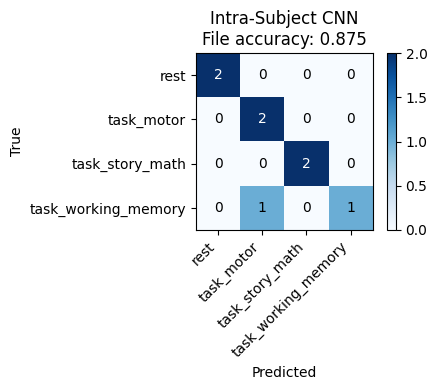

In [ ]:
cm  = metrics['file_confusion_matrix']
fig, ax = plt.subplots(figsize=(5, 4))
im  = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(4))
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Intra-Subject CNN\nFile accuracy: {metrics["file_acc"]:.3f}')
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()


---

# CNN Cross-Subject

Same spatiotemporal CNN architecture, adapted for the cross-subject setting:
- **Grid search uses LOSO** (leave-one-subject-out) over the 2 training subjects — required by the protocol
- **`kernel_temp` is fixed** to the best value from the intra grid search (temporal scale generalises across subjects)
- **`use_instance_norm`** is added as a grid search axis — replaces BatchNorm after the spatial conv with InstanceNorm to avoid accumulating subject-specific statistics during training
- **Final model** trains on all cross-train subjects with no val split
- **Evaluation** on 3 separate held-out test subjects; report per-subject and mean file accuracy

## 9. Cross Data Loading

Same preprocessing config as intra (`downsample_factor=4`, `window_size=512`, `stride=256`).

We pre-window the 3 test sets here so evaluation at the end is a single forward pass per set.

In [8]:
from protocol_utils import make_leave_one_subject_out_folds

cross_train_files = list_files(paths.cross_train)
cross_test_files  = [
    ('test1', list_files(paths.cross_test1)),
    ('test2', list_files(paths.cross_test2)),
    ('test3', list_files(paths.cross_test3)),
]

# pre-window each test set
cross_test_data = []
for name, files in cross_test_files:
    X_t, y_t, groups_t = make_windows(files, cfg)
    cross_test_data.append((name, X_t, y_t, groups_t))
    print(f'{name}: {X_t.shape}  ({len(files)} files)')

print(f'\nCross-train files: {len(cross_train_files)}')

test1: (1056, 248, 512)  (16 files)
test2: (1056, 248, 512)  (16 files)
test3: (1056, 248, 512)  (16 files)

Cross-train files: 64


## 10. LOSO Fold Construction

`make_leave_one_subject_out_folds` groups files by subject ID (parsed from the filename) and returns 2 folds: each fold holds out one subject as val and trains on the other.

For each fold we call `make_windows` separately so we have clean `(X_train, y_train)` and `(X_val, y_val, val_groups)` arrays per fold. `val_groups` tracks which file each window came from, enabling file-level accuracy during the grid search.

In [10]:
folds = make_leave_one_subject_out_folds(cross_train_files)

fold_data = []
for val_subject, fold_train_files, fold_val_files in folds:
    X_tr, y_tr, _          = make_windows(fold_train_files, cfg)
    X_vl, y_vl, vl_groups  = make_windows(fold_val_files,   cfg)
    fold_data.append({
        'val_subject':  val_subject,
        'X_train':      X_tr,
        'y_train':      y_tr,
        'X_val':        X_vl,
        'y_val':        y_vl,
        'val_groups':   vl_groups,
    })
    print(f'Fold val={val_subject}: train {X_tr.shape}, val {X_vl.shape}')

Fold val=113922: train (2112, 248, 512), val (2112, 248, 512)
Fold val=164636: train (2112, 248, 512), val (2112, 248, 512)


## 11. Model — InstanceNorm Option

Identical to `CNNOnly` except the BatchNorm after the **spatial conv** can be swapped for `InstanceNorm2d`.

**Why the spatial conv's norm?** The spatial conv learns which sensors co-activate — patterns that are subject-specific. BatchNorm accumulates running mean/var from training subjects; at test time on an unseen subject, those running stats may be off. InstanceNorm normalises each sample independently so no subject-specific statistics are stored, making the model more robust to unseen subjects.

The temporal BatchNorm is left unchanged — z-score normalisation already removes per-sensor amplitude differences, so that layer is less exposed to subject shift.

In [11]:
class CNNCross(nn.Module):
    """
    Spatiotemporal CNN for cross-subject classification.

    Identical to CNNOnly but the spatial conv's normalisation layer is
    switchable: BatchNorm2d (default) or InstanceNorm2d (use_instance_norm=True).

    InstanceNorm normalises each sample independently -- no accumulated
    subject statistics -- which is more robust on unseen test subjects.
    """
    def __init__(self, n_channels=248, n_classes=4, window_size=512,
                 n_filters=40, kernel_temp=25, pool_size=75, pool_stride=15,
                 dropout=0.5, use_instance_norm=False):
        super().__init__()

        # temporal conv: (B, 1, 248, W) -> (B, n_filters, 248, W - kernel_temp + 1)
        self.temporal = nn.Sequential(
            nn.Conv2d(1, n_filters, kernel_size=(1, kernel_temp), bias=False),
            nn.BatchNorm2d(n_filters),  # kept as BN: z-score already normalised inputs
        )

        # choose normalisation for the spatial conv
        # InstanceNorm2d with affine=True keeps learnable scale/shift
        # but does not accumulate subject-specific running statistics
        spatial_norm = (
            nn.InstanceNorm2d(n_filters, affine=True)
            if use_instance_norm
            else nn.BatchNorm2d(n_filters)
        )

        # spatial conv: (B, n_filters, 248, T') -> (B, n_filters, 1, T'')
        self.spatial = nn.Sequential(
            nn.Conv2d(n_filters, n_filters, kernel_size=(n_channels, 1), bias=False),
            spatial_norm,
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, pool_size), stride=(1, pool_stride)),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Linear(n_filters, n_classes)

    def forward(self, x):
        x = self.temporal(x)       # (B, n_filters, 248, T')
        x = self.spatial(x)        # (B, n_filters, 1,   T'')
        x = x.squeeze(2)           # (B, n_filters, T'')
        x = x.permute(0, 2, 1)     # (B, T'', n_filters)
        x = x.mean(dim=1)          # (B, n_filters)  -- GAP
        return self.classifier(x)  # (B, 4)           -- logits


# sanity check
_m   = CNNCross(use_instance_norm=True).to(device)
_in  = torch.zeros(2, 1, 248, 512).to(device)
_out = _m(_in)
print(f'Parameters (BN)  : {sum(p.numel() for p in CNNCross().parameters()):,}')
print(f'Parameters (IN)  : {sum(p.numel() for p in _m.parameters()):,}')
print(f'Output shape     : {tuple(_out.shape)}')
del _m, _in, _out

Parameters (BN)  : 398,124
Parameters (IN)  : 398,124
Output shape     : (2, 4)


## 12. Cross Comparison: BatchNorm vs InstanceNorm

All hyperparameters are fixed from the intra grid search result. The only cross-specific question is whether replacing BatchNorm with InstanceNorm on the spatial conv helps generalise to unseen subjects.

**2 configs × 2 LOSO folds = 4 training runs.**

| Parameter | Value |
|---|---|
| `kernel_temp` | fixed from intra best |
| `n_filters` | fixed from intra best |
| `dropout` | fixed from intra best |
| `use_instance_norm` | **False, True** ← only axis swept |

In [12]:
def train_one_config_cross(kernel_temp, n_filters, dropout, use_instance_norm,
                           fold_data, max_epochs=30, patience=5,
                           lr=5e-4, weight_decay=1e-4):
    """
    Train one config on both LOSO folds; return mean val file_acc and
    mean best epoch (used later to set the final training length).
    """
    fold_results = []

    for fold in fold_data:
        loader = DataLoader(
            MEGWindowDataset(fold['X_train'], fold['y_train']),
            batch_size=64, shuffle=True, num_workers=0,
        )
        model = CNNCross(
            n_channels=248, n_classes=4, window_size=512,
            n_filters=n_filters, kernel_temp=kernel_temp,
            dropout=dropout, use_instance_norm=use_instance_norm,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss()

        best_val_acc, best_epoch, best_state = 0.0, 0, None
        patience_counter = 0

        for epoch in range(1, max_epochs + 1):
            run_epoch(loader, model, criterion, optimizer)
            val_file_acc = get_val_file_acc(
                model, fold['X_val'], fold['y_val'], fold['val_groups']
            )
            if val_loss < best_val_loss:
                best_val_loss     = val_loss
                best_epoch       = epoch
                best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break

        fold_results.append({'val_file_acc': best_val_acc, 'best_epoch': best_epoch})
        print(f'      fold val={fold["val_subject"]}: '
              f'file_acc={best_val_acc:.3f}  epoch={best_epoch}')

    mean_val  = float(np.mean([r['val_file_acc'] for r in fold_results]))
    # ceil of mean epoch so we don't under-train the final model
    mean_ep   = int(np.ceil(np.mean([r['best_epoch'] for r in fold_results])))
    return {'mean_val_file_acc': mean_val, 'mean_best_epoch': mean_ep, 'fold_results': fold_results}

In [ ]:
# all hyperparams fixed from intra; only vary use_instance_norm
print(f'Fixed from intra grid search:')
print(f'  kernel_temp={best["kernel_temp"]},  n_filters={best["n_filters"]},  dropout={best["dropout"]}')
print(f'\n2 configs x 2 LOSO folds = 4 training runs\n')

cross_configs = [
    {'use_instance_norm': False},
    {'use_instance_norm': True},
]

gs_cross_results = []
for cfg_item in cross_configs:
    print(f'  use_instance_norm={cfg_item["use_instance_norm"]}')
    result = train_one_config_cross(
        kernel_temp=best['kernel_temp'],
        n_filters=best['n_filters'],
        dropout=best['dropout'],
        use_instance_norm=cfg_item['use_instance_norm'],
        fold_data=fold_data,
    )
    gs_cross_results.append({
        'kernel_temp': best['kernel_temp'],
        'n_filters':   best['n_filters'],
        'dropout':     best['dropout'],
        **cfg_item,
        **result,
    })
    print(f'  -> mean_val_file_acc={result["mean_val_file_acc"]:.3f}  mean_epoch={result["mean_best_epoch"]}\n')

gs_cross_results.sort(key=lambda r: r['mean_val_file_acc'], reverse=True)
best_cross = gs_cross_results[0]
print(f'Best: use_instance_norm={best_cross["use_instance_norm"]}  '
      f'mean_val_file_acc={best_cross["mean_val_file_acc"]:.3f}')


Fixed from intra grid search:
  kernel_temp=51,  n_filters=40,  dropout=0.3

2 configs x 2 LOSO folds = 4 training runs

  use_instance_norm=False
      fold val=113922: file_acc=0.750  epoch=12
      fold val=164636: file_acc=0.656  epoch=13
  -> mean_val_file_acc=0.703  mean_epoch=13

  use_instance_norm=True
      fold val=113922: file_acc=0.562  epoch=13
      fold val=164636: file_acc=0.438  epoch=11
  -> mean_val_file_acc=0.500  mean_epoch=12

Best: use_instance_norm=False  mean_val_file_acc=0.703


In [16]:
best_cross = {
    'kernel_temp': 51,
    'n_filters': 40,
    'dropout': 0.3,
    'use_instance_norm': False,
    'mean_best_epoch': 13,  # from LOSO CV
}

## 13. Cross Grid Search Results

In [16]:
print(f'  {"instance_norm":>13} {"mean_val_acc":>13} {"mean_epoch":>11}')
print('  ' + '-' * 42)
for r in gs_cross_results:
    marker = '  <- best' if r is gs_cross_results[0] else ''
    print(
        f'  {str(r["use_instance_norm"]):>13} '
        f'{r["mean_val_file_acc"]:>13.3f} '
        f'{r["mean_best_epoch"]:>11}{marker}'
    )

print(
    f'\nBest: use_instance_norm={best_cross["use_instance_norm"]},  '
    f'mean_val_file_acc={best_cross["mean_val_file_acc"]:.3f},  '
    f'mean_epoch={best_cross["mean_best_epoch"]}'
)


  instance_norm  mean_val_acc  mean_epoch
  ------------------------------------------
          False         0.703          13  <- best
           True         0.500          12

Best: use_instance_norm=False,  mean_val_file_acc=0.703,  mean_epoch=13


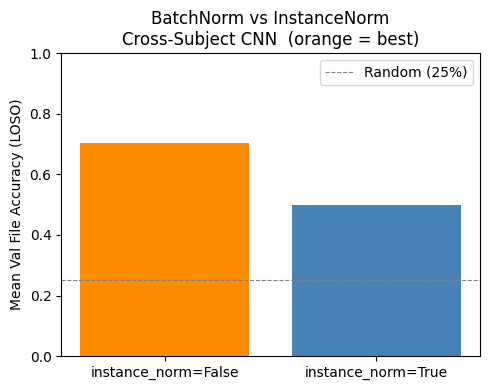

In [17]:
labels_c = [f'instance_norm={r["use_instance_norm"]}' for r in gs_cross_results]
accs_c   = [r['mean_val_file_acc'] for r in gs_cross_results]
colors_c = ['darkorange' if i == 0 else 'steelblue' for i in range(len(gs_cross_results))]

plt.figure(figsize=(5, 4))
plt.bar(labels_c, accs_c, color=colors_c)
plt.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Random (25%)')
plt.ylabel('Mean Val File Accuracy (LOSO)')
plt.title('BatchNorm vs InstanceNorm\nCross-Subject CNN  (orange = best)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


## 14. Final Cross-Subject Model

Train on **all cross-train files** (both subjects, no val split) for `mean_best_epoch` epochs. No held-out val at this stage — hyperparameters are fixed and all available cross-subject training data is used.

In [17]:
X_cross_all, y_cross_all, _ = make_windows(cross_train_files, cfg)
cross_all_ds     = MEGWindowDataset(X_cross_all, y_cross_all)
cross_all_loader = DataLoader(cross_all_ds, batch_size=64, shuffle=True, num_workers=0)
print(f'Full cross-train set: {X_cross_all.shape}  ({len(cross_train_files)} files)')

final_cross_model = CNNCross(
    n_channels=248, n_classes=4, window_size=512,
    n_filters=best_cross['n_filters'],
    kernel_temp=best_cross['kernel_temp'],
    dropout=best_cross['dropout'],
    use_instance_norm=best_cross['use_instance_norm'],
).to(device)

optimizer = torch.optim.Adam(final_cross_model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

n_epochs = best_cross['mean_best_epoch']
print(f'Training for {n_epochs} epochs...\n')
for epoch in range(1, n_epochs + 1):
    loss, win_acc = run_epoch(cross_all_loader, final_cross_model, criterion, optimizer)
    print(f'  Epoch {epoch:02d}/{n_epochs} | loss {loss:.4f} | window_acc {win_acc:.3f}')

torch.save(final_cross_model.state_dict(), 'cnn_cross_final.pt')
print('\nSaved cnn_cross_final.pt')

Full cross-train set: (4224, 248, 512)  (64 files)
Training for 13 epochs...

  Epoch 01/13 | loss 1.3206 | window_acc 0.412
  Epoch 02/13 | loss 1.2091 | window_acc 0.526
  Epoch 03/13 | loss 1.1021 | window_acc 0.609
  Epoch 04/13 | loss 1.0121 | window_acc 0.665
  Epoch 05/13 | loss 0.9304 | window_acc 0.707
  Epoch 06/13 | loss 0.8440 | window_acc 0.761
  Epoch 07/13 | loss 0.7762 | window_acc 0.773
  Epoch 08/13 | loss 0.7073 | window_acc 0.811
  Epoch 09/13 | loss 0.6401 | window_acc 0.853
  Epoch 10/13 | loss 0.5798 | window_acc 0.875
  Epoch 11/13 | loss 0.5212 | window_acc 0.893
  Epoch 12/13 | loss 0.4768 | window_acc 0.906
  Epoch 13/13 | loss 0.4340 | window_acc 0.917

Saved cnn_cross_final.pt


## 15. Test Evaluation — 3 Unseen Subjects

Each test subject is evaluated independently. Primary metric is **mean file accuracy across the 3 subjects**.

> Note: each test set has 16 files → accuracy moves in steps of 6.25%.

In [18]:
def predict_logits_cross(windows):
    """
    Protocol-compatible inference function for the cross model.
    Input : (n_windows, 248, 512)  float32
    Output: (n_windows, 4)         float32  logits
    """
    final_cross_model.eval()
    all_logits = []
    with torch.no_grad():
        for i in range(0, len(windows), 128):
            x = torch.from_numpy(windows[i:i+128]).unsqueeze(1).to(device)
            all_logits.append(final_cross_model(x).cpu().numpy())
    return np.concatenate(all_logits, axis=0)


print(f'{"Subject":<10} {"Window acc":>11} {"File acc":>10}')
print('-' * 34)
test_metrics = []
for name, X_t, y_t, groups_t in cross_test_data:
    m = summarize_logits(predict_logits_cross(X_t), y_t, groups_t)
    test_metrics.append((name, m))
    print(f'{name:<10} {m["window_acc"]:>11.3f} {m["file_acc"]:>10.3f}')

mean_file_acc = np.mean([m['file_acc'] for _, m in test_metrics])
print(f'\nMean file accuracy: {mean_file_acc:.3f}  <- primary metric')

Subject     Window acc   File acc
----------------------------------
test1            0.512      0.812
test2            0.378      0.500
test3            0.566      0.688

Mean file accuracy: 0.667  <- primary metric


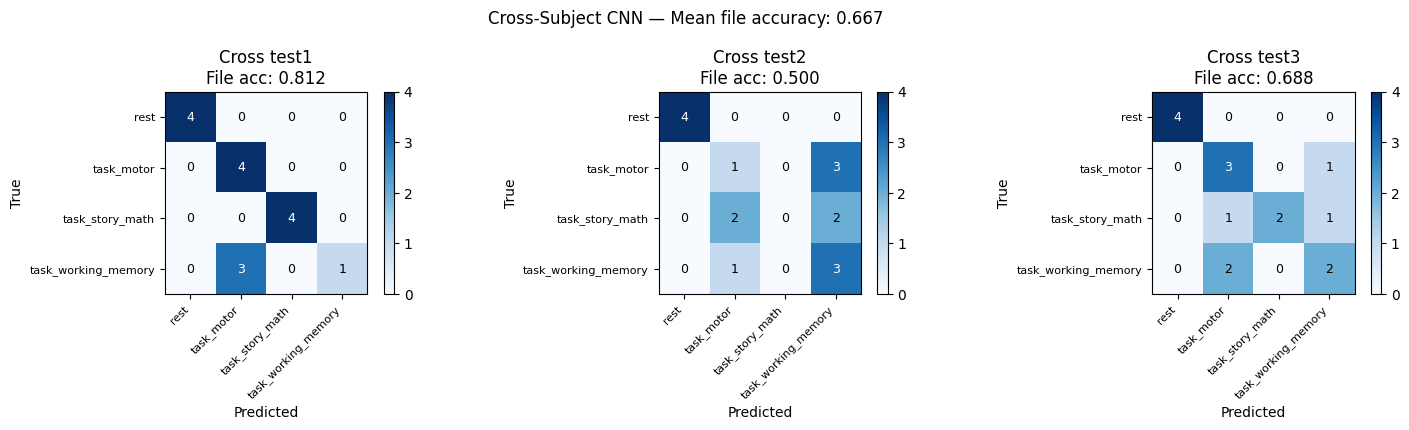

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, m) in zip(axes, test_metrics):
    cm = m['file_confusion_matrix']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(4))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(4))
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Cross {name}\nFile acc: {m["file_acc"]:.3f}')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=9,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.colorbar(im, ax=ax)

plt.suptitle(
    f'Cross-Subject CNN — Mean file accuracy: {mean_file_acc:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()